In [1]:
import numpy as np
import matplotlib.pyplot as plt

from gps import gps, prn

# Setup

In [2]:
f_s = 2.6e6
x = np.fromfile("data/gpssim.bin", dtype=np.int8)[0:int(f_s*2)]
x = np.sign(x)
# x[x == 0] = 1

x = x[::2].astype(np.complex64) + 1j*x[1::2].astype(np.complex64)
# x.imag = x.imag * 0

# Acquisition

In [6]:
results = gps.acquisition(x, f_s, 10e3, 500)

# Refine frequency estimates
for i in range(len(results)):
    old = results[i][1]
    results[i][1], _ = gps.fine_acquisition(x, f_s, 4092, 8, results[i][0], results[i][2])

# Tracking

In [19]:
i = 0
sv = results[i][0]
freq_est = results[i][1]
code_est = results[i][2]

(
    res_iq,
    res_carr_freq,
    res_carr_err,
    res_code_freq,
    res_code_err,
    res_code_phase,
    res_code_pos,
) = gps.tracking(x, f_s, sv, freq_est, code_est, debug_results=True)

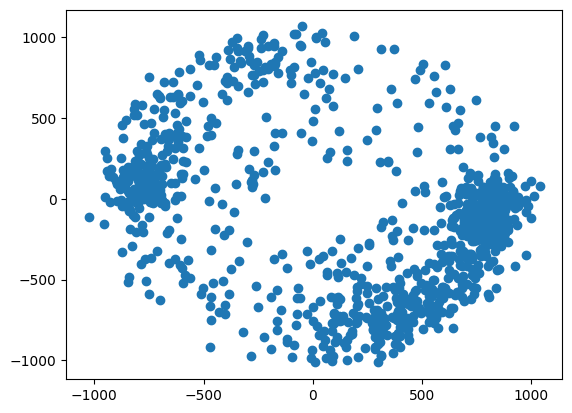

In [20]:
plt.scatter(res_iq.real, res_iq.imag)

In [21]:
print(res_code_pos[-1])
print(res_code_phase[-1])

2598692
0.09075744617223336
